In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

In [2]:
import pandas as pd
from src.visualization.plots import plot_age_distribution, height_distribution, weight_distribution, football_countries, show_correlation_matrix, save_fig
from src.data.calculations import calculate_correlation_matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('../data/raw/fifa_players.csv')
data

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,...,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,...,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,...,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,...,58,38,15,54,52,50,53,16,18,17


### Feature analysis
---

#### 1. Age analysis

In [4]:
# Descriptive statistics for player age
data['age'].describe()

count    17954.000000
mean        25.565445
std          4.705708
min         17.000000
25%         22.000000
50%         25.000000
75%         29.000000
max         46.000000
Name: age, dtype: float64

In [5]:
# No missing values
data['age'].isna().sum()

np.int64(0)

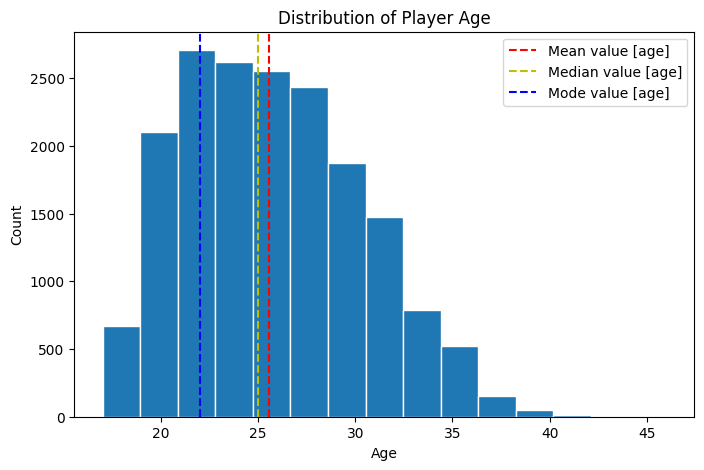

In [6]:
plot_age_distribution(data)

#### 2. height_cm / weight_kgs analysis

In [7]:
data['height_cm'].describe()

count    17954.000000
mean       174.946921
std         14.029449
min        152.400000
25%        154.940000
50%        175.260000
75%        185.420000
max        205.740000
Name: height_cm, dtype: float64

In [8]:
# No missing values
data['height_cm'].isna().sum()

np.int64(0)

In [9]:
# Here, we examine the players’ height and whether lower height could be related to younger age.
# However, we can see that even the shortest football players are between 17 and 42 years old.
# These physical characteristics are not always a leading factor,
# but it is certainly important to analyze this indicator in order to understand what is typical.
data[data['height_cm'] < 160]['age'].describe()

count    4515.000000
mean       25.375194
std         4.707351
min        17.000000
25%        22.000000
50%        25.000000
75%        29.000000
max        42.000000
Name: age, dtype: float64

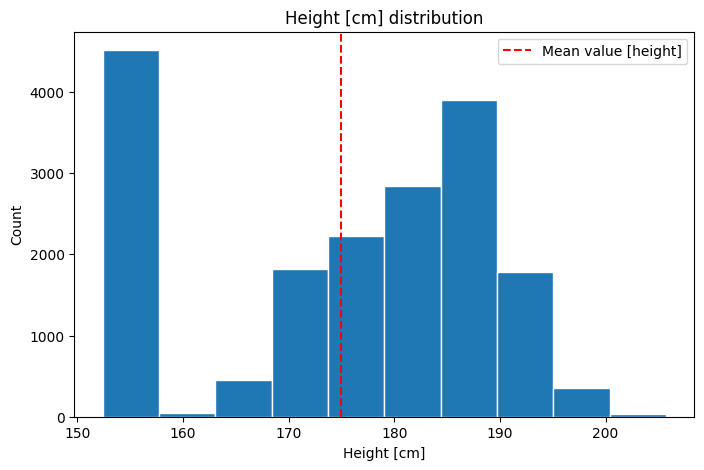

In [10]:
height_distribution(data)

In [11]:
data['weight_kgs'].describe()

count    17954.000000
mean        75.301047
std          7.083684
min         49.900000
25%         69.900000
50%         74.800000
75%         79.800000
max        110.200000
Name: weight_kgs, dtype: float64

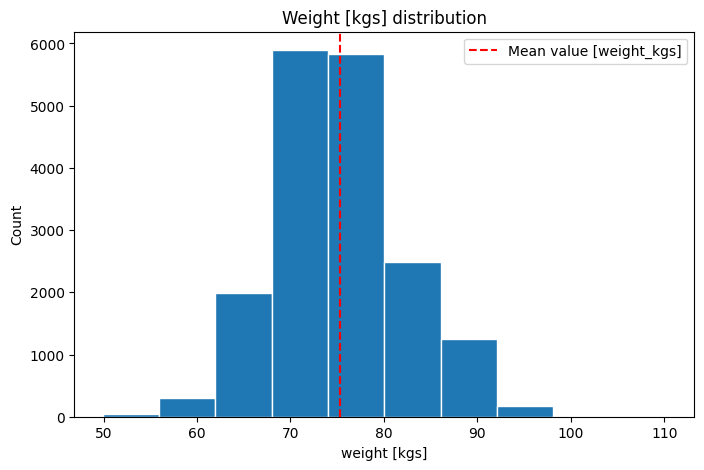

In [12]:
weight_distribution(data)

There are also other missing values in some of the features in the dataset, but their number is not very large.

During the data preprocessing stage, we will decide how to handle them. One possible approach is to fill them with the average wage of the team the player belongs to.

At this stage, no action will be taken.

#### 3. nationality analysis

In [13]:
top_10_football_countries = data['nationality'].value_counts()
top_10_football_countries

nationality
England                 1658
Germany                 1199
Spain                   1070
France                   925
Argentina                904
                        ... 
Kuwait                     1
New Caledonia              1
Oman                       1
São Tomé & Príncipe        1
United Arab Emirates       1
Name: count, Length: 160, dtype: int64

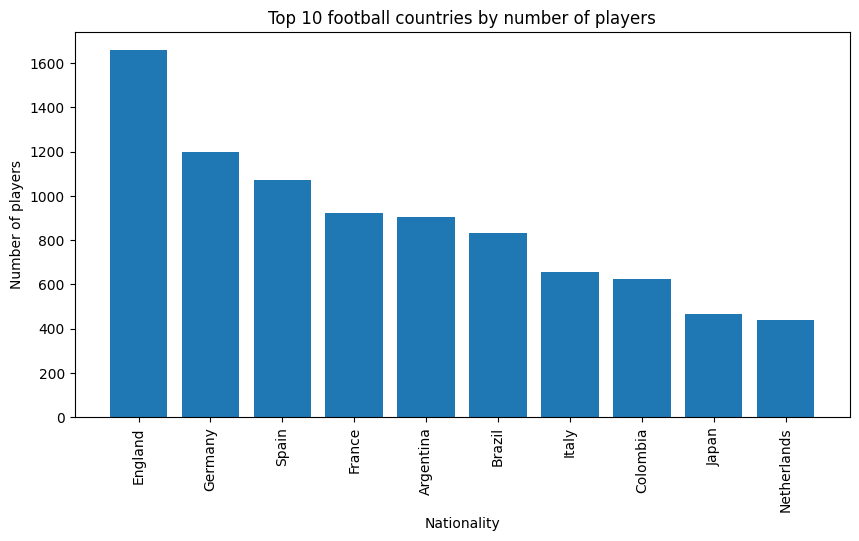

In [14]:
football_countries(data)

### Interesting observation

An interesting observation from the chart is the presence of **Japan** in the top 10 countries by number of football players included in the dataset.

This result shows that the dataset is not dominated only by the traditional European and South American football nations.

#### 4. Personal performance

In [15]:
data

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,...,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,...,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,...,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,...,58,38,15,54,52,50,53,16,18,17


In [16]:
data.columns

Index(['name', 'full_name', 'birth_date', 'age', 'height_cm', 'weight_kgs',
       'positions', 'nationality', 'overall_rating', 'potential', 'value_euro',
       'wage_euro', 'preferred_foot', 'international_reputation(1-5)',
       'weak_foot(1-5)', 'skill_moves(1-5)', 'body_type',
       'release_clause_euro', 'national_team', 'national_rating',
       'national_team_position', 'national_jersey_number', 'crossing',
       'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'dribbling', 'curve', 'freekick_accuracy', 'long_passing',
       'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions',
       'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
       'aggression', 'interceptions', 'positioning', 'vision', 'penalties',
       'composure', 'marking', 'standing_tackle', 'sliding_tackle'],
      dtype='object')

In [17]:
pp_features = ['crossing',
               'finishing',
               'heading_accuracy',
               'short_passing',
               'volleys',
               'dribbling',
               'curve',
               'freekick_accuracy',
               'long_passing',
               'ball_control',
               'acceleration',
               'sprint_speed',
               'agility',
               'reactions',
               'balance',
               'shot_power',
               'jumping',
               'stamina',
               'strength',
               'long_shots',
               'aggression',
               'interceptions',
               'positioning',
               'vision',
               'penalties',
               'composure',
               'marking',
               'standing_tackle',
               'sliding_tackle'
               ]

In [18]:
personal_performance_data = data[pp_features]

In [19]:
personal_performance_data.isna().sum()

crossing             0
finishing            0
heading_accuracy     0
short_passing        0
volleys              0
dribbling            0
curve                0
freekick_accuracy    0
long_passing         0
ball_control         0
acceleration         0
sprint_speed         0
agility              0
reactions            0
balance              0
shot_power           0
jumping              0
stamina              0
strength             0
long_shots           0
aggression           0
interceptions        0
positioning          0
vision               0
penalties            0
composure            0
marking              0
standing_tackle      0
sliding_tackle       0
dtype: int64

In [20]:
# personal_performance_data.to_csv('personal_performance_data.csv', index=False)

In [21]:
pp_data = pd.read_csv('../data/processed/personal_performance_data.csv')
pp_data

,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,86,95,70,92,86,97,93,94,89,96,...,94,48,22,94,94,75,96,33,28,26
1,88,81,52,91,80,84,86,87,89,91,...,89,46,56,84,91,67,88,59,57,22
2,80,75,75,86,85,87,85,82,90,90,...,82,78,64,82,88,82,87,63,67,67
3,86,77,56,85,74,90,87,77,78,93,...,84,34,26,83,87,61,83,51,24,22
4,30,22,83,68,14,69,28,28,60,63,...,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,57,61,60,66,37,64,53,47,61,66,...,54,69,41,60,64,63,56,40,20,18
17950,50,19,53,55,31,52,26,28,43,53,...,22,62,55,42,39,32,52,53,64,60
17951,11,9,13,26,9,12,13,12,24,18,...,9,27,10,5,25,16,47,9,12,13
17952,42,60,55,49,49,57,47,39,37,56,...,58,38,15,54,52,50,53,16,18,17


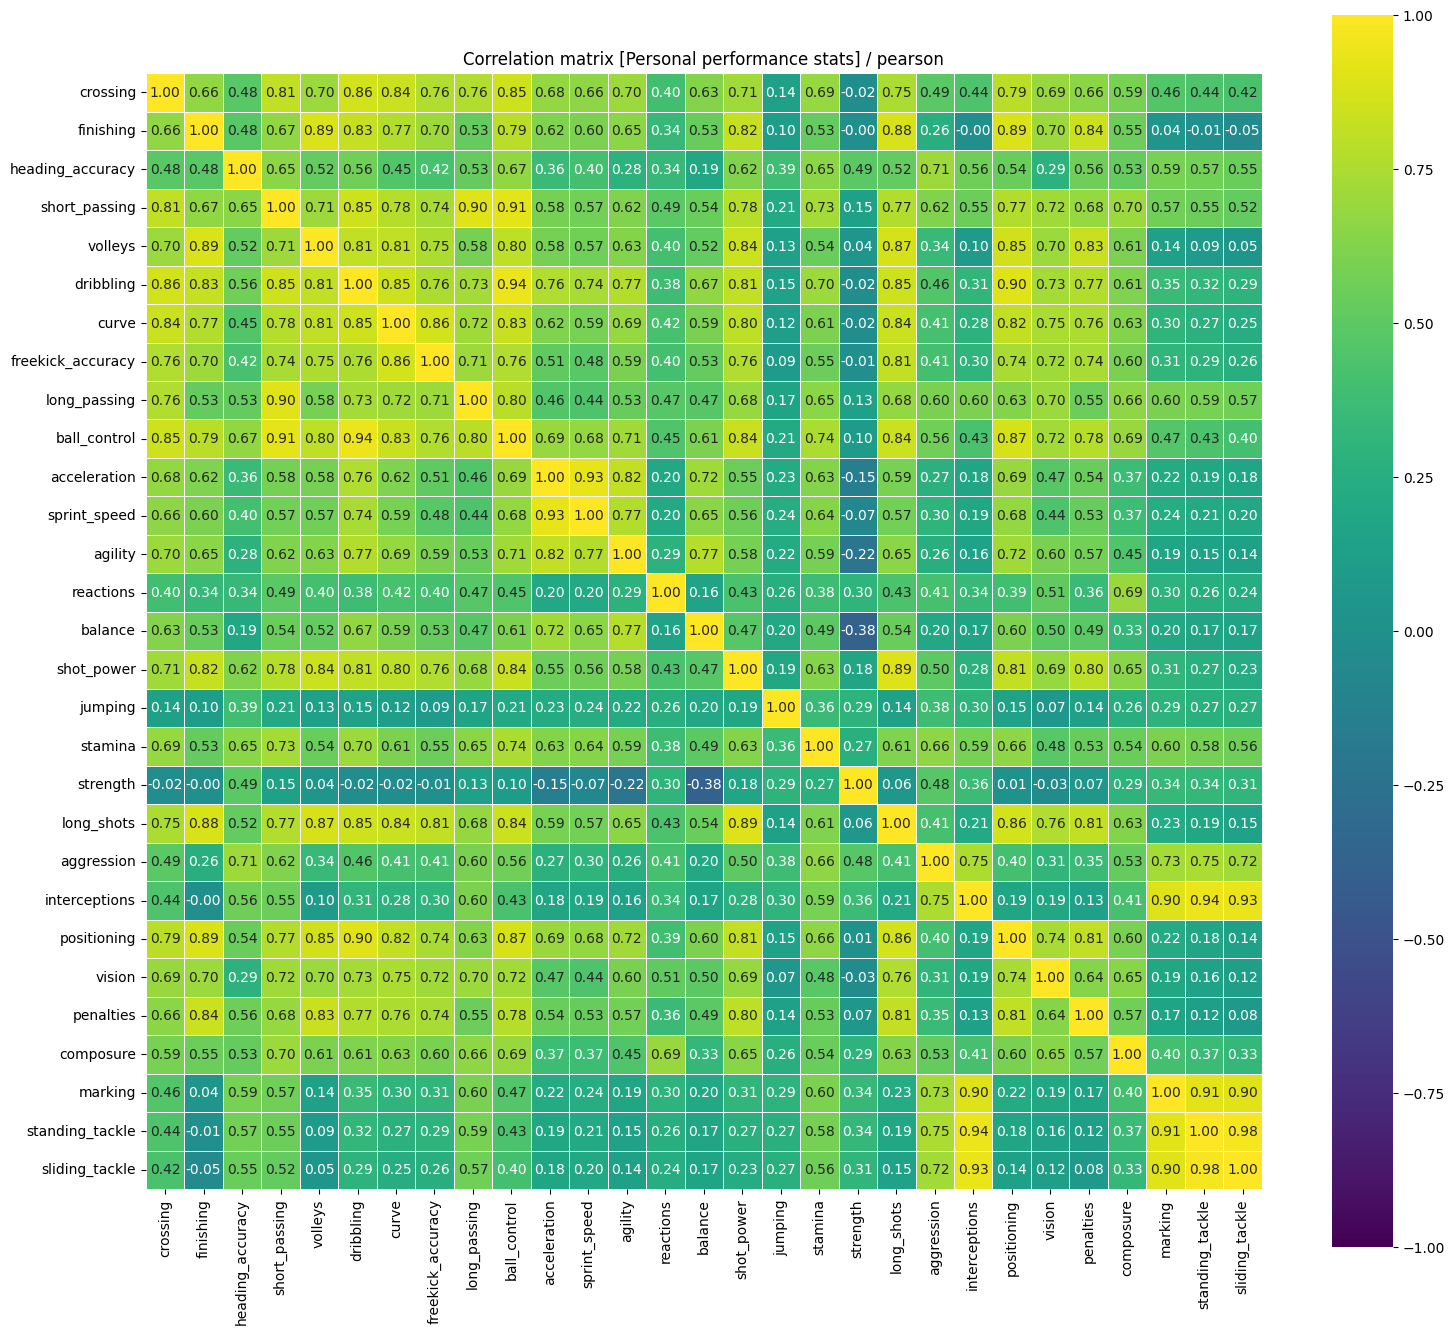

In [22]:
# Calculate the Pearson correlation matrix for the selected personal performance features.
correlation_matrix_pearson = calculate_correlation_matrix(pp_data, 'pearson')

# Visualize the Pearson correlation matrix as a heatmap.
# The figure will also be saved with the given file name.
show_correlation_matrix(
    correlation_matrix_pearson,
    corr_method='pearson',
    figure_name='pearson_corr_personal_stats.png'
)

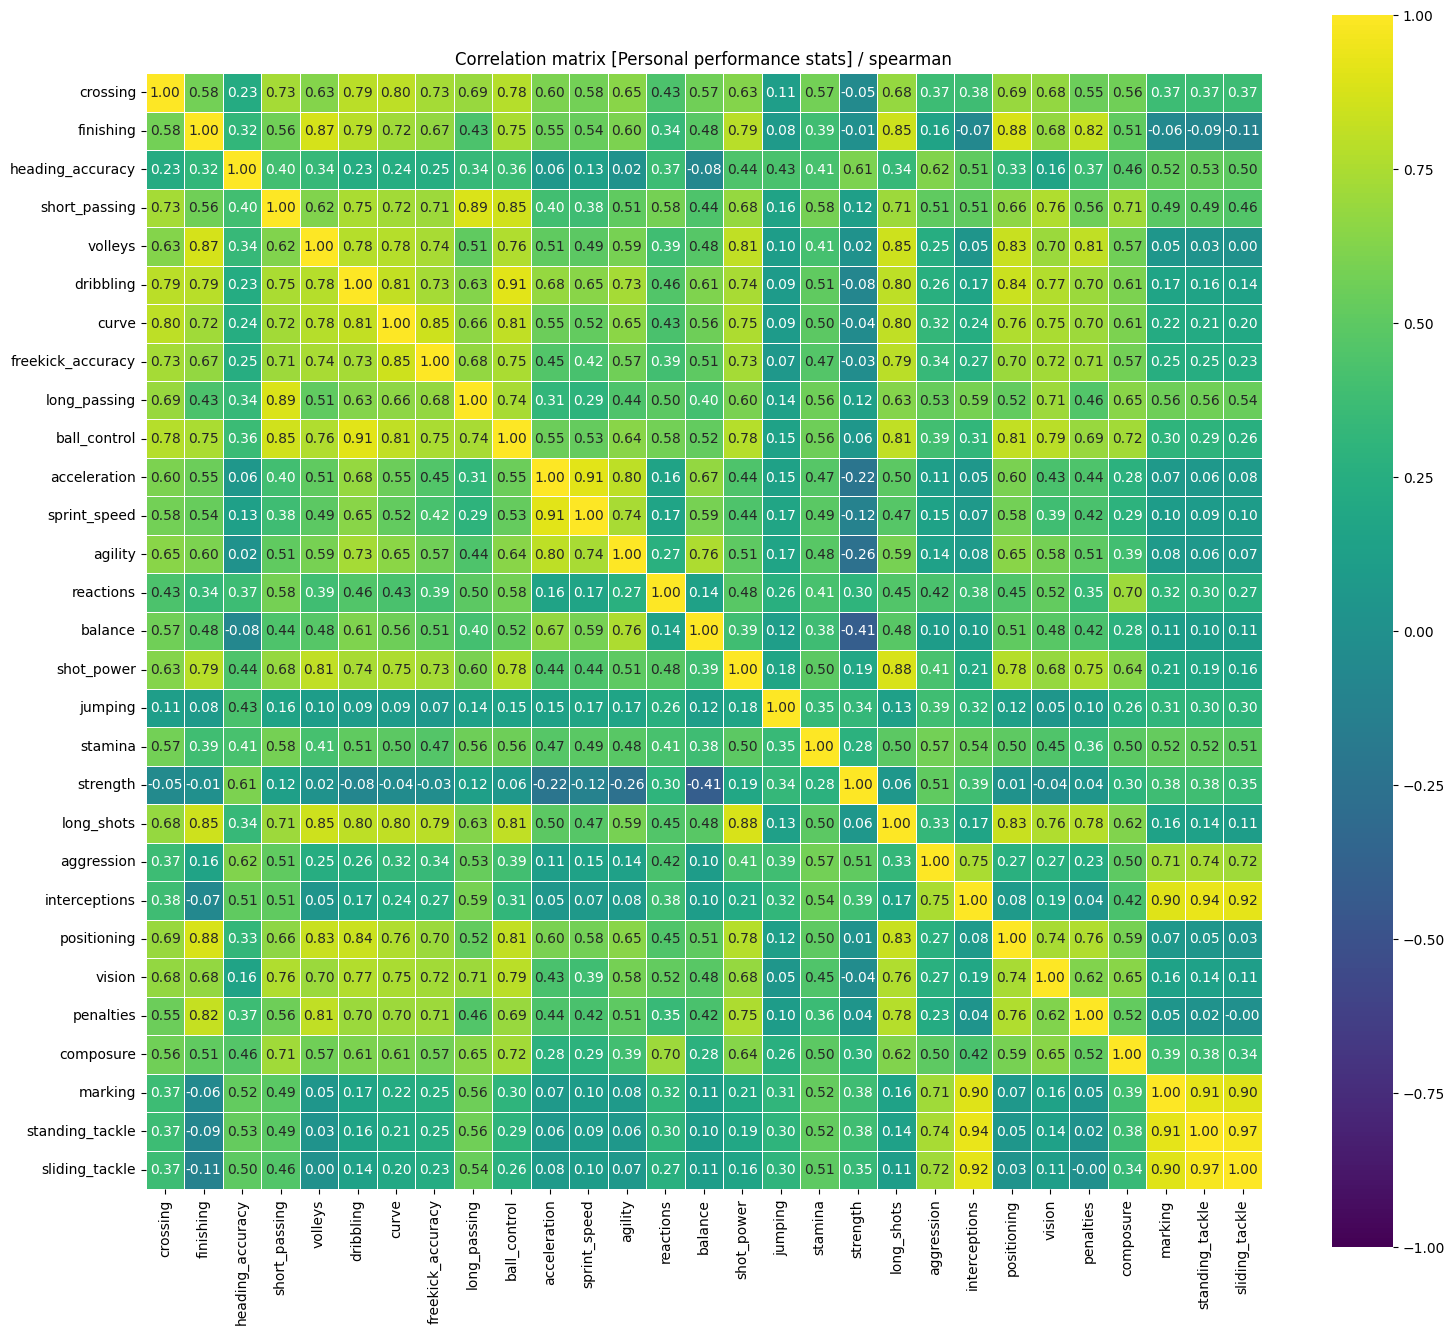

In [23]:
# Calculate the Spearman correlation matrix for the selected personal performance features.
correlation_matrix_spearman = calculate_correlation_matrix(pp_data, 'spearman')

# Visualize the Spearman correlation matrix as a heatmap.
# The figure will also be saved with the given file name.
show_correlation_matrix(
    correlation_matrix_spearman,
    corr_method='spearman',
    figure_name='spearman_corr_personal_stats'
)

## Final Conclusions from the Pearson and Spearman Correlation Matrices

The Pearson and Spearman correlation matrices show very similar patterns. This means that the relationships between the personal performance features are stable and not strongly dependent on the correlation method used.

Pearson measures mainly linear relationships, while Spearman measures monotonic relationships. Since both matrices produce similar results, we can conclude that most relationships between these football performance attributes are consistent and reliable.

---

## 1. Strong correlations between technical attacking skills

There is a strong positive correlation between several attacking and technical attributes:

- `dribbling`
- `ball_control`
- `curve`
- `volleys`
- `finishing`
- `long_shots`
- `positioning`
- `shot_power`
- `penalties`

This suggests that players who are technically strong in one attacking area are usually strong in other attacking areas as well.

For example, players with high `dribbling` often also have high `ball_control`, `curve`, `positioning`, and `long_shots`.

### Conclusion

Attacking technical skills form one clear group of related features.

---

## 2. Passing-related features are strongly connected

The features:

- `short_passing`
- `long_passing`
- `vision`
- `ball_control`
- `crossing`

show strong positive correlations.

This means that players with good passing ability usually also have good vision and ball control.

### Conclusion

Passing, vision, and ball control are closely connected and can be interpreted as a playmaking skill group.

---

## 3. Defensive features form a separate strong group

There is a very strong correlation between:

- `marking`
- `standing_tackle`
- `sliding_tackle`
- `interceptions`
- `aggression`

The strongest correlations are between:

- `standing_tackle` and `sliding_tackle`
- `marking` and `standing_tackle`
- `interceptions` and `standing_tackle`

### Conclusion

Defensive skills are strongly related to each other and form a separate defensive performance group.

---

## 4. Speed and movement attributes are strongly related

The features:

- `acceleration`
- `sprint_speed`
- `agility`
- `balance`

show strong positive relationships.

The strongest one is between `acceleration` and `sprint_speed`, which is expected because both describe a player's speed profile.

### Conclusion

Physical movement attributes form another clear feature group.

---

## 5. Strength has weak or negative correlation with technical skills

`strength` has weak or slightly negative correlations with several technical and movement-based features such as:

- `dribbling`
- `curve`
- `agility`
- `balance`
- `acceleration`

This suggests that physically stronger players are not necessarily more technical or agile.

### Conclusion

Strength represents a different type of player profile and does not strongly belong to the technical skill group.

---

## 6. Jumping is mostly weakly correlated

`jumping` has generally weak correlations with most other attributes.

It has some moderate relation with `heading_accuracy`, which is logical because jumping helps in aerial duels.

### Conclusion

Jumping is a more independent physical attribute and does not strongly explain overall technical or defensive ability.

---

## 7. Reactions and composure are more general quality indicators

`reactions` and `composure` have moderate correlations with many different features.

They are not limited to only attacking, passing, or defending.

### Conclusion

These two features may represent more general player quality, experience, or decision-making ability.

---

## 8. Pearson and Spearman results are very similar

The Pearson and Spearman matrices show nearly the same main relationships.

This means that the correlations are not only linear but also generally monotonic.

### Conclusion

The selected personal performance features have stable relationships, so Pearson correlation is appropriate for this analysis. Spearman confirms the same overall structure.

---

## Overall Final Conclusion

The correlation analysis shows that the personal performance attributes can be grouped into several main categories:

1. Attacking technical skills
2. Passing and playmaking skills
3. Defensive skills
4. Speed and movement skills
5. Physical strength and aerial attributes

The strongest relationships are found inside these groups. This means that many football attributes are not independent from each other.

For example, a player with high attacking technical skills usually has high values in several related attacking features, while a strong defensive player usually has high values across multiple defensive features.

The similarity between Pearson and Spearman confirms that the results are stable and reliable for further analysis.